In [1]:
file_read = "001_fit"
file_write = "003_coefs"

In [2]:
import polars as pl

df_coefs = pl.read_parquet(f"{file_read}_coefs.parquet")

In [3]:
n_features_min = 19

In [4]:
df_coefs_ = df_coefs.filter(pl.col("n_features") == n_features_min)

In [5]:
df_coefs_

pyridone_test,n_features,alpha,2_zero,3_zero,4_zero,6_zero,7_zero,9_zero,12_zero,14_zero,16_zero,18_zero,19_zero,21_zero,46_zero,68_zero,91_zero,148_zero,157_zero,161_zero,232_zero,234_zero,235_zero,237_zero,240_zero,247_zero,252_zero,255_zero,270_zero,271_zero,275_zero,293_zero,324_zero,327_zero,355_zero,357_zero,415_zero,442_zero,465_zero,469_zero,494_zero,505_zero,506_zero,507_zero,519_zero,538_zero,540_zero,543_zero,575_zero,597_zero,602_zero,605_zero,642_zero
i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,19,3.27,-0.171401,null,null,null,0.28738,-0.230059,0.098309,null,null,null,null,null,null,0.109891,-0.153677,null,-0.282652,null,-0.287078,0.273799,null,null,-0.160171,null,null,null,null,0.25378,null,null,-0.160627,-0.130338,null,null,null,null,null,-0.271669,0.165942,null,-0.310632,0.072454,null,null,null,0.388169,null,-0.127591,null,null,null
1,19,3.02,null,null,null,0.123767,0.203157,-0.225702,null,null,null,null,null,null,null,null,-0.198158,null,-0.276538,0.138556,-0.097054,0.362358,0.184879,null,-0.125746,null,null,null,null,0.334196,null,null,-0.467542,-0.126067,null,null,-0.220294,null,null,-0.258736,0.248923,null,-0.317679,null,null,null,null,0.341862,-0.108114,null,null,null,null
2,19,0.97,-0.173689,null,null,-0.217517,0.433434,-0.080633,0.150008,0.089467,0.043022,null,null,null,null,null,-0.203113,null,-0.356922,null,-0.255086,0.4481,null,null,-0.256655,null,null,null,null,0.446343,null,null,-0.389028,null,null,null,null,null,null,-0.301295,0.260477,null,-0.338577,null,null,null,null,0.386605,null,0.11252,null,null,null
3,19,2.71,-0.135868,null,null,null,0.342299,-0.307087,0.130729,null,null,null,null,null,null,null,-0.224962,-0.150992,-0.294224,null,-0.271762,0.343287,0.214841,null,-0.13785,null,null,null,null,0.319278,null,null,-0.16541,-0.102529,null,null,null,null,null,-0.207404,0.180142,null,-0.20744,null,null,null,null,0.212704,null,-0.152919,null,null,null
4,19,2.98,null,null,null,null,0.278203,-0.249463,0.099276,null,null,null,null,null,null,0.089252,-0.217026,null,-0.204597,null,-0.35126,0.25959,0.196141,null,-0.151289,null,null,null,null,0.283833,null,null,-0.280883,-0.086394,null,null,null,null,null,-0.255275,0.164409,null,-0.313825,0.111555,null,null,null,0.406887,null,-0.202848,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
8,19,2.25,-0.130686,null,-0.096192,-0.003742,0.315092,-0.131111,0.114939,null,null,null,null,null,null,0.086901,-0.131092,null,-0.296033,null,-0.267754,0.323515,null,null,-0.249004,null,null,null,null,0.262049,null,null,-0.231821,null,null,null,null,null,null,-0.137004,0.162665,null,-0.302058,null,null,null,null,0.365683,null,-0.019768,null,null,null
9,19,8.61,-0.104447,null,null,null,0.206925,-0.184389,null,0.102437,null,null,0.100945,null,null,0.107619,-0.094117,null,-0.206911,null,-0.272538,0.187318,null,null,-0.103554,null,null,null,null,0.162285,null,null,-0.157917,null,-0.089235,null,null,null,null,-0.140063,0.157045,null,-0.235747,null,null,null,null,0.250705,null,-0.175053,null,null,null
10,19,1.08,null,-0.134533,null,null,0.535802,-0.203276,null,null,null,null,null,null,null,null,-0.202737,null,-0.427588,null,-0.261034,0.285659,0.304462,null,-0.370485,null,null,0.187173,null,0.397844,null,null,-0.535725,-0.117165,null,null,null,null,null,-0.179863,0.239138,null,-0.272556,0.125057,null,null,null,0.422864,null,-0.032071,null,null,null


In [6]:
columns_feat = [column for column in df_coefs_.columns if "zero" in column]

In [7]:
data = df_coefs_[columns_feat].to_numpy()

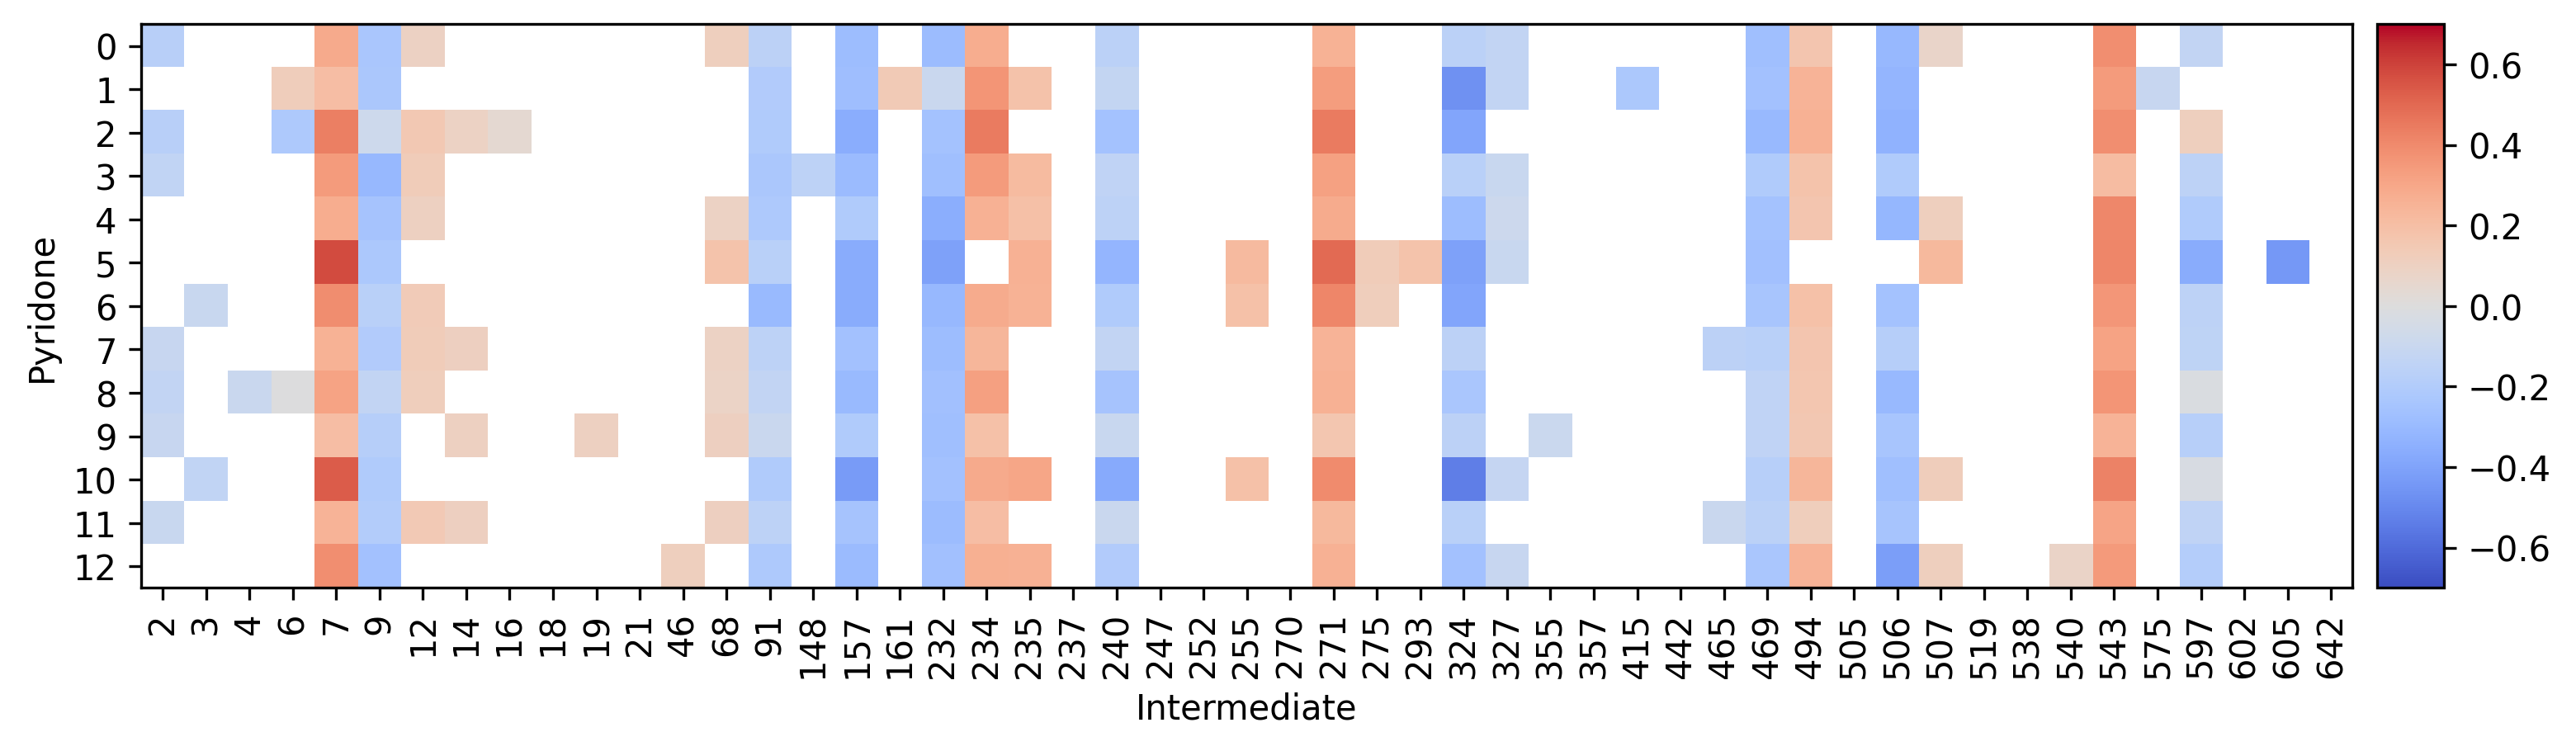

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(12, 4), dpi=300)

im = ax.imshow(data, vmin=-0.7, vmax=0.7, cmap="coolwarm")

ax.set_xlabel("Intermediate")
ax.set_ylabel("Pyridone")
ax.set_xticks(np.arange(data.shape[1]))
ax.set_yticks(np.arange(data.shape[0]))
ax.set_xticklabels([c[:-5] for c in columns_feat], rotation=90)
ax.set_yticklabels(df_coefs_["pyridone_test"])

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
fig.colorbar(im, cax=cax)

plt.savefig(
    f"{file_write}_imshow.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [9]:
data_mean = df_coefs_[columns_feat].fill_null(0.0).mean().to_numpy().ravel()
data_std = df_coefs_[columns_feat].fill_null(0.0).std(ddof=1).to_numpy().ravel()
data_std = np.where(data_std == 0.0, np.nan, data_std)

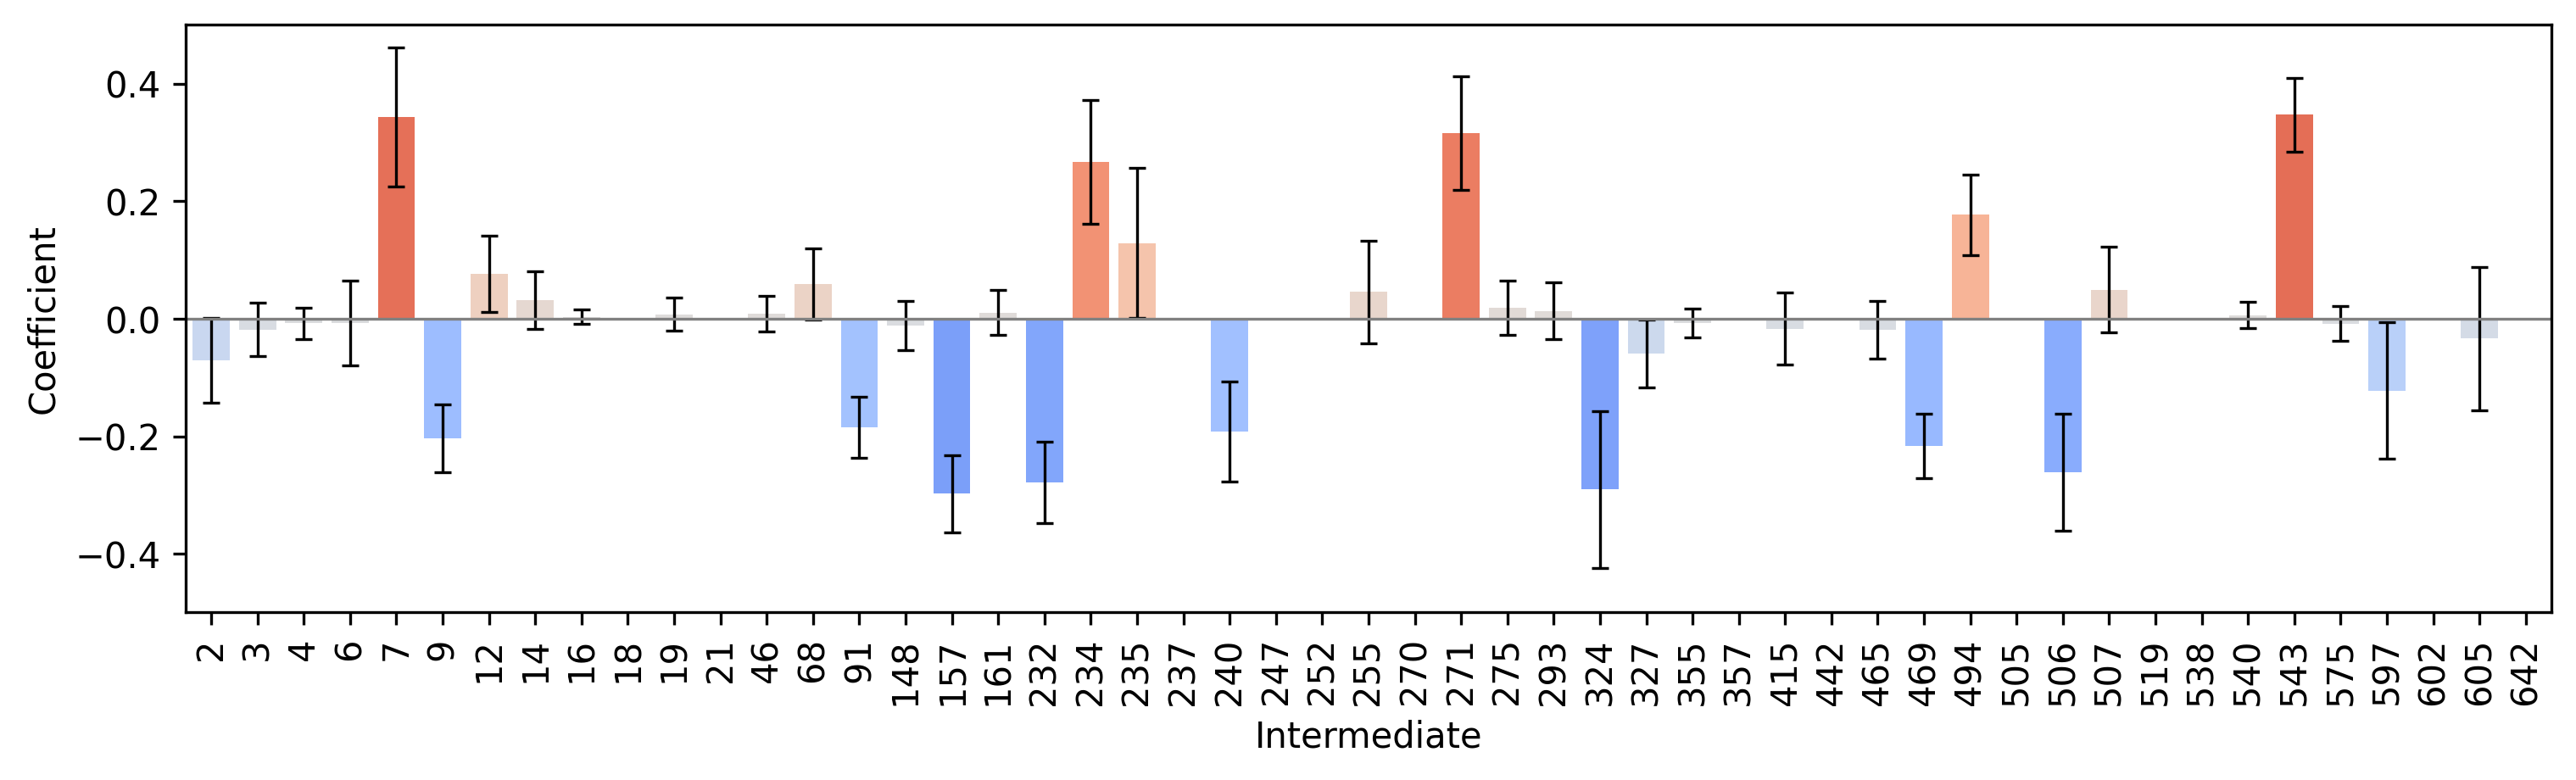

In [10]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(12, 3), dpi=300)

norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-0.5, vmax=0.5)
colors = plt.cm.coolwarm(norm(data_mean))
error_kw = dict(elinewidth=0.8, capthick=0.8)
ax.bar(
    np.arange(len(data_mean)),
    data_mean,
    yerr=data_std,
    color=colors,
    capsize=2.5,
    error_kw=error_kw
)
ax.axhline(0, color="gray", linewidth=0.8)

ax.set_xlabel("Intermediate")
ax.set_ylabel("Coefficient")
ax.set_xticks(np.arange(len(data_mean)))
ax.set_xticklabels([c[:-5] for c in columns_feat], rotation=90)
ax.margins(x=0.003)
ax.set_ylim(-0.5, 0.5)

plt.savefig(
    f"{file_write}_bar.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()